# GRAM-DIFF Paper-Style Figures

This notebook generates paper-style NMSE curves using the current repo implementation. The channel model is labeled **Our Rayleigh** because the repo currently simulates i.i.d. Rayleigh channels. The pretrained diffusion prior can be switched between the copied Fesl 3GPP and QuaDRiGa checkpoints below.

The guidance schedules follow the GRAM-DIFF paper:

- `lambda_like,t = lambda_like * beta_t * gate(SNR)`
- `lambda_gram,t = lambda_gram * sqrt(beta_t)`
- per-step Gram update norm clipping


In [1]:
from pathlib import Path
import sys
import time

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from gram_diff_mimo.diffusion import load_fesl_pretrained_denoiser
from gram_diff_mimo.mimo.channel import generate_rayleigh_channel, mimo_observation
from gram_diff_mimo.mimo.estimators import (
    angular_receive_gram,
    gram_diff_channel_estimate,
    least_squares_from_pilots,
)
from gram_diff_mimo.mimo.metrics import nmse
from gram_diff_mimo.mimo.pilots import identity_pilots

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 220,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 9,
    "lines.linewidth": 2.0,
    "lines.markersize": 5,
})


In [6]:
# Configuration
CHANNEL_LABEL = "Our Rayleigh"

# Switch this to the QuaDRiGa checkpoint if you want to compare priors:
# MODEL_DIR = PROJECT_ROOT / "best_models_fesl_dm_paper" / "quadriga_LOS"
# PRIOR_LABEL = "Fesl QuaDRiGa LOS pretrained prior"
MODEL_DIR = PROJECT_ROOT / "best_models_fesl_dm_paper" / "3gpp_path=3"
PRIOR_LABEL = "Fesl 3GPP pretrained prior"

DEVICE = "auto"
SEED = 0
N_RX = 64
N_TX = 16

# Increase N_TRIALS for smoother curves. The SNR grid is generated from range settings.
SNR_DB_MIN = -15
SNR_DB_MAX = 15
N_SNR_POINTS = 31
SNR_DB_VALUES = np.linspace(SNR_DB_MIN, SNR_DB_MAX, N_SNR_POINTS)
N_DATA_VALUES = [20, 200, 2000]
N_TRIALS = 3

# Global guidance strengths. Per-step schedules are created from these values.
LAMBDA_LIKE = 0.01
LAMBDA_GRAM = 0.01
GRAM_CLIP_NORM = 0.5

# SNR gate for likelihood guidance. Set LIKELIHOOD_GATE_SNR0 = None to disable it.
LIKELIHOOD_GATE_SNR0 = 1.0
LIKELIHOOD_GATE_DELTA = 0.5

np.random.seed(SEED)
denoiser = load_fesl_pretrained_denoiser(MODEL_DIR, device=DEVICE)
print(f"Channel: {CHANNEL_LABEL}")
print(f"Prior: {PRIOR_LABEL}")
print(f"Model dir: {MODEL_DIR}")
print(f"Device selected by loader: {denoiser.device}")


Channel: Our Rayleigh
Prior: Fesl 3GPP pretrained prior
Model dir: /home/r/projects/gram-diff-mimo/best_models_fesl_dm_paper/3gpp_path=3
Device selected by loader: cuda


In [7]:
def random_data_symbols(n_tx: int, n_data: int) -> np.ndarray:
    return (np.random.randn(n_tx, n_data) + 1j * np.random.randn(n_tx, n_data)) / np.sqrt(2.0)


def estimate_variants(H, Y_p, Y_d, X_p, noise_variance):
    R_tilde_oracle = angular_receive_gram(H @ H.conj().T)
    common = dict(
        Y_p=Y_p,
        X_p=X_p,
        noise_variance=noise_variance,
        denoiser=denoiser,
        alpha_bar=denoiser.alpha_bar,
        betas=denoiser.betas,
    )

    estimates = {
        "LS": least_squares_from_pilots(Y_p=Y_p, X_p=X_p),
        "DM": gram_diff_channel_estimate(Y_d=None, **common),
        "DM + Likelihood": gram_diff_channel_estimate(
            Y_d=None,
            lambda_like=LAMBDA_LIKE,
            likelihood_gate_snr0=LIKELIHOOD_GATE_SNR0,
            likelihood_gate_delta=LIKELIHOOD_GATE_DELTA,
            **common,
        ),
        "DM + Gram (est)": gram_diff_channel_estimate(
            Y_d=Y_d,
            lambda_gram=LAMBDA_GRAM,
            gram_clip_norm=GRAM_CLIP_NORM,
            **common,
        ),
        "DM + Gram (oracle)": gram_diff_channel_estimate(
            Y_d=None,
            R_tilde_hat=R_tilde_oracle,
            lambda_gram=LAMBDA_GRAM,
            gram_clip_norm=GRAM_CLIP_NORM,
            **common,
        ),
        "Joint (est)": gram_diff_channel_estimate(
            Y_d=Y_d,
            lambda_like=LAMBDA_LIKE,
            lambda_gram=LAMBDA_GRAM,
            gram_clip_norm=GRAM_CLIP_NORM,
            likelihood_gate_snr0=LIKELIHOOD_GATE_SNR0,
            likelihood_gate_delta=LIKELIHOOD_GATE_DELTA,
            **common,
        ),
        "Joint (oracle)": gram_diff_channel_estimate(
            Y_d=None,
            R_tilde_hat=R_tilde_oracle,
            lambda_like=LAMBDA_LIKE,
            lambda_gram=LAMBDA_GRAM,
            gram_clip_norm=GRAM_CLIP_NORM,
            likelihood_gate_snr0=LIKELIHOOD_GATE_SNR0,
            likelihood_gate_delta=LIKELIHOOD_GATE_DELTA,
            **common,
        ),
    }
    return {name: nmse(H, H_hat) for name, H_hat in estimates.items()}


def run_grid():
    X_p = identity_pilots(N_TX)
    rows = []
    start = time.time()
    total = len(SNR_DB_VALUES) * len(N_DATA_VALUES) * N_TRIALS
    done = 0
    for snr_db in SNR_DB_VALUES:
        noise_variance = 10.0 ** (-snr_db / 10.0)
        for n_data in N_DATA_VALUES:
            values_by_variant = {}
            for _ in range(N_TRIALS):
                H = generate_rayleigh_channel(n_rx=N_RX, n_tx=N_TX)
                Y_p, _ = mimo_observation(H, X_p, noise_variance=noise_variance)
                X_d = random_data_symbols(N_TX, n_data)
                Y_d, _ = mimo_observation(H, X_d, noise_variance=noise_variance)
                trial = estimate_variants(H, Y_p, Y_d, X_p, noise_variance)
                for variant, value in trial.items():
                    values_by_variant.setdefault(variant, []).append(value)
                done += 1
                print(f"completed {done}/{total}", end="\r")

            for variant, values in values_by_variant.items():
                rows.append({
                    "snr_db": snr_db,
                    "n_data": n_data,
                    "variant": variant,
                    "mean_nmse": float(np.mean(values)),
                    "std_nmse": float(np.std(values)),
                })
    print(f"\nfinished in {time.time() - start:.1f}s")
    return rows


rows = run_grid()
rows[:3]


completed 279/279
finished in 38.0s


[{'snr_db': np.float64(-15.0),
  'n_data': 20,
  'variant': 'LS',
  'mean_nmse': 32.26933759778823,
  'std_nmse': 0.11356673972219544},
 {'snr_db': np.float64(-15.0),
  'n_data': 20,
  'variant': 'DM',
  'mean_nmse': 1.4089093304582516,
  'std_nmse': 0.2008940739395721},
 {'snr_db': np.float64(-15.0),
  'n_data': 20,
  'variant': 'DM + Likelihood',
  'mean_nmse': 1.4111227916257503,
  'std_nmse': 0.2015114377392415}]

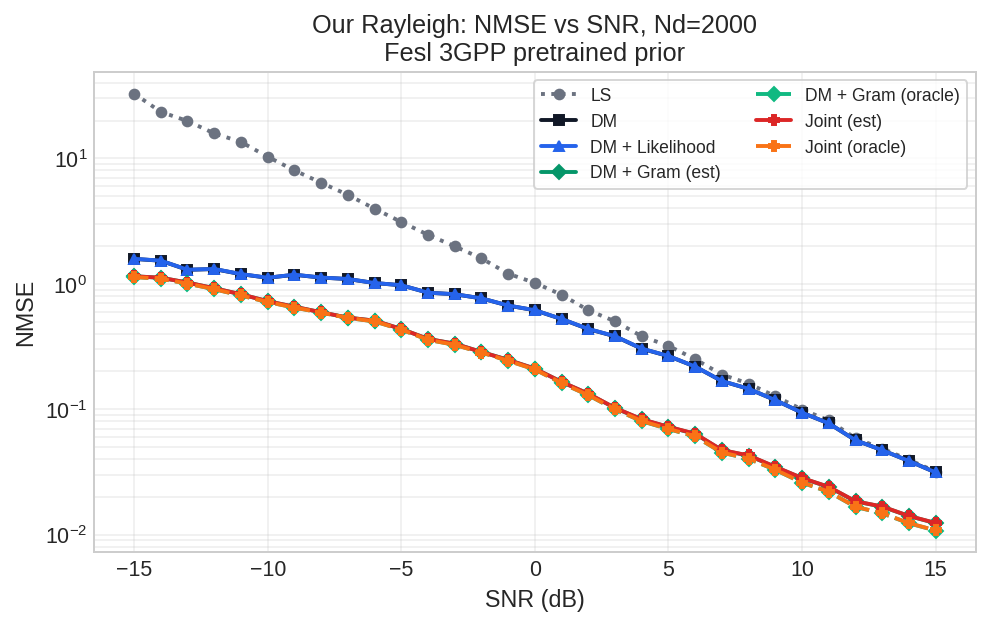

In [8]:
def lookup(rows, *, snr_db=None, n_data=None, variant=None):
    out = []
    for row in rows:
        if snr_db is not None and row["snr_db"] != snr_db:
            continue
        if n_data is not None and row["n_data"] != n_data:
            continue
        if variant is not None and row["variant"] != variant:
            continue
        out.append(row)
    return out


VARIANT_STYLE = {
    "LS": dict(color="#6b7280", marker="o", linestyle=":"),
    "DM": dict(color="#111827", marker="s", linestyle="-"),
    "DM + Likelihood": dict(color="#2563eb", marker="^", linestyle="-"),
    "DM + Gram (est)": dict(color="#059669", marker="D", linestyle="-"),
    "DM + Gram (oracle)": dict(color="#10b981", marker="D", linestyle="--"),
    "Joint (est)": dict(color="#dc2626", marker="P", linestyle="-"),
    "Joint (oracle)": dict(color="#f97316", marker="P", linestyle="--"),
}


def plot_nmse_vs_snr(rows, n_data):
    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    variants = list(VARIANT_STYLE)
    for variant in variants:
        data = sorted(lookup(rows, n_data=n_data, variant=variant), key=lambda r: r["snr_db"])
        if not data:
            continue
        x = [r["snr_db"] for r in data]
        y = [r["mean_nmse"] for r in data]
        ax.semilogy(x, y, label=variant, **VARIANT_STYLE[variant])
    ax.set_title(f"{CHANNEL_LABEL}: NMSE vs SNR, Nd={n_data}\n{PRIOR_LABEL}")
    ax.set_xlabel("SNR (dB)")
    ax.set_ylabel("NMSE")
    ax.grid(True, which="both", alpha=0.35)
    ax.legend(ncol=2, frameon=True)
    fig.tight_layout()
    return fig, ax


fig, ax = plot_nmse_vs_snr(rows, n_data=max(N_DATA_VALUES))


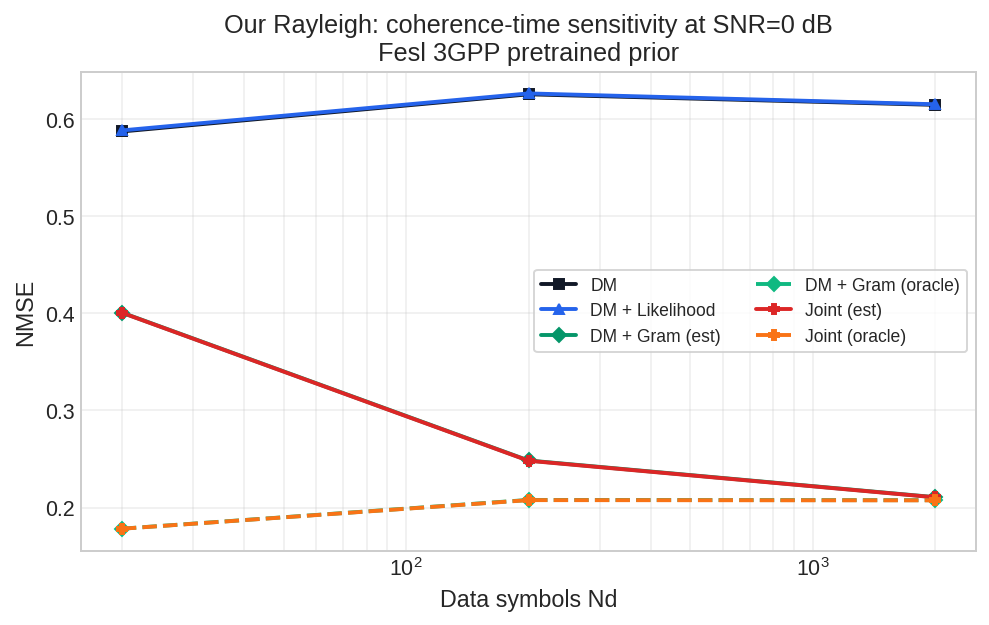

In [9]:
def plot_nmse_vs_nd(rows, snr_db):
    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    variants = [
        "DM",
        "DM + Likelihood",
        "DM + Gram (est)",
        "DM + Gram (oracle)",
        "Joint (est)",
        "Joint (oracle)",
    ]
    for variant in variants:
        data = sorted(lookup(rows, snr_db=snr_db, variant=variant), key=lambda r: r["n_data"])
        if not data:
            continue
        x = [r["n_data"] for r in data]
        y = [r["mean_nmse"] for r in data]
        ax.semilogx(x, y, label=variant, **VARIANT_STYLE[variant])
    ax.set_title(f"{CHANNEL_LABEL}: coherence-time sensitivity at SNR={snr_db} dB\n{PRIOR_LABEL}")
    ax.set_xlabel("Data symbols Nd")
    ax.set_ylabel("NMSE")
    ax.grid(True, which="both", alpha=0.35)
    ax.legend(ncol=2, frameon=True)
    fig.tight_layout()
    return fig, ax


fig, ax = plot_nmse_vs_nd(rows, snr_db=0)


In [ ]:
# Optional: save figures under outputs/, which is already gitignored.
SAVE_FIGURES = False
if SAVE_FIGURES:
    out_dir = PROJECT_ROOT / "outputs" / "figures"
    out_dir.mkdir(parents=True, exist_ok=True)
    plot_nmse_vs_snr(rows, n_data=max(N_DATA_VALUES))[0].savefig(out_dir / "rayleigh_nmse_vs_snr.png", bbox_inches="tight")
    plot_nmse_vs_nd(rows, snr_db=0)[0].savefig(out_dir / "rayleigh_nmse_vs_nd.png", bbox_inches="tight")
    print(f"Saved figures to {out_dir}")
